# 🚦 Phase 1: Ingesting Parking & Violation Data for Proactive Intelligence

**The Challenge:** Traffic enforcement is currently reactive and patrol-based. We lack visibility into *when* and *where* on-street parking and spillover events choke our intersections.

Before we can build AI-driven parking intelligence, we must establish a clean data foundation. In this phase, we ingest the raw, anonymized violation dataset to extract the critical spatio-temporal coordinates. By converting raw timestamps into structured temporal features (Hour, Day of Week) and isolating valid coordinates, we transition the raw data into an analyzable format to track exactly when commercial areas and metro stations experience the highest parking stress.

In [ ]:
!pip install pandas numpy matplotlib seaborn folium scikit-learn xgboost lightgbm h3 joblib optuna

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import xgboost as xgb
import lightgbm as lgb
import h3
import joblib
import os

# Set visualization style
sns.set_theme(style="whitegrid")
import warnings
warnings.filterwarnings('ignore')

In [2]:
# 1. Load the data
df = pd.read_csv('jan to may police violation_anonymized791b166.csv')

# 2. Clean spatial and temporal data
df = df.dropna(subset=['latitude', 'longitude', 'created_datetime'])
df['created_datetime'] = pd.to_datetime(df['created_datetime'], format='ISO8601')
df['hour'] = df['created_datetime'].dt.hour
df['day_of_week'] = df['created_datetime'].dt.day_name()
df['junction_name'] = df['junction_name'].fillna('No Junction')

print(df.shape)
print(df.memory_usage(deep=True).sum() / 1024**2, "MB")

# 3. View the first 5 rows to verify
display(df[['latitude', 'longitude', 'day_of_week', 'hour', 'junction_name', 'violation_type']].head(5))
# display(df.head(3))

(298450, 26)
352.59458923339844 MB


,latitude,longitude,day_of_week,hour,junction_name,violation_type
0,12.925557,77.618665,Monday,0,No Junction,"[""WRONG PARKING"",""PARKING NEAR ROAD CROSSING""]"
1,12.905463,77.700778,Friday,22,No Junction,"[""NO PARKING""]"
2,12.925449,77.618504,Monday,0,No Junction,"[""WRONG PARKING"",""PARKING IN A MAIN ROAD""]"
3,12.956521,77.518618,Thursday,6,No Junction,"[""NO PARKING""]"
4,12.977767,77.580545,Wednesday,4,BTP044 - Sagar Theatre Junction,"[""NO PARKING""]"


# 🗺️ Phase 2: Spatial Aggregation – Why H3 HEX Over DBSCAN?

**The Challenge:** We need to map nearly 300,000 individual parking violations into actionable enforcement zones. 

**The Architectural Choice: H3 HEX vs. DBSCAN**
For spatial clustering of 298,450 rows, traditional density-based algorithms like DBSCAN are a bottleneck. 
* **DBSCAN Time Complexity:** DBSCAN requires calculating distance matrices between points. Even with spatial indexing (like KD-Trees), its complexity is $O(N \log N)$, and in dense urban datasets, it degrades toward its worst-case $O(N^2)$. Furthermore, DBSCAN generates arbitrary, morphing shapes that are difficult to assign to patrol units.
* **H3 Time Complexity:** Uber's Hexagonal Hierarchical Spatial Index (H3) uses a hash-based coordinate system. The time complexity to map a coordinate to a hexagon is $O(1)$, making the total process strictly $O(N)$. 

**The Business Value:** H3 is not just mathematically superior; it creates fixed, uniform geographic boundaries (Resolution 9 hexagons) that act as standardized "Patrol Beats." By aggregating violations into these hexagons, we instantly transform a chaotic scatterplot of 300K reactive reports into structured, high-priority zones.

In [3]:
print(f"Mapping {len(df)} Coordinates to H3 Hexagons...")

HEX_RESOLUTION = 9

df["hex_id"] = [
    h3.latlng_to_cell(lat, lon, HEX_RESOLUTION)
    for lat, lon in zip(df.latitude, df.longitude)
]

hex_stats = df.groupby("hex_id").agg(
    total_volume=("id","count"),
    unique_days=("created_datetime","nunique"),
    unique_hours=("hour","nunique"),
    unique_violation_types=("violation_type","nunique"),
    dominant_violation=("violation_type", lambda x:x.mode()[0]),
    center_lat=("latitude","mean"),
    center_lon=("longitude","mean")
).reset_index()

hex_stats["repeat_factor"] = (
    hex_stats["total_volume"] /
    hex_stats["unique_days"]
)

# Optional: We apply a "Micro-Filter" just to drop pure anomalies/data-entry errors 
# (e.g., hexagons with fewer than 3 violations over the entire 5 months).
# This keeps ~98% of the data while dropping meaningless noise.

MINIMUM_VIOLATIONS = 3
hotspots_base = hex_stats[hex_stats.total_volume >= MINIMUM_VIOLATIONS].copy()

print(f"Total Patrol Beats (Hexagons) retained: {hotspots_base.shape[0]}")

Mapping 298450 Coordinates to H3 Hexagons...
Total Patrol Beats (Hexagons) retained: 1941


# 📊 Phase 3: Quantifying the Impact on Traffic Flow

**The Challenge:** The problem statement notes that it is "difficult to prioritize enforcement zones." All illegal parking is bad, but a car parked near a metro station during rush hour chokes the carriageway far more than a car in a quiet suburb at midnight.

**The Solution:** I engineer a **Dynamic Congestion Impact Score** (0-100) to explicitly quantify the severity of each hotspot. This creates a data-driven hierarchy for targeted enforcement:
* **Total Volume (45%):** The sheer density of violations in the zone.
* **Repeat Factor (25%):** How consistently the area experiences spillover parking day-over-day.
* **Violation Diversity (15%):** The mix of infractions occurring.
* **Peak Hour Multiplier (10%):** Heavier weighting for choke points active during commute hours (8-11 AM, 5-8 PM).
* **Junction Weight (5%):** Additional penalty for parking that directly chokes structural intersections.

In [4]:
# Now, the hotspot_records contain the full spectrum: from quiet streets to chaotic junctions.
hotspot_records = df[df.hex_id.isin(hotspots_base.hex_id)]

temporal = hotspot_records.groupby("hex_id").agg(
    peak_hour=("hour", lambda x:x.mode()[0]),
    peak_day=("day_of_week", lambda x:x.mode()[0]),
    primary_junction=("junction_name", lambda x:x.mode()[0]),
    dominant_violation=("violation_type", lambda x:x.mode()[0])
).reset_index()

final_hotspots = hotspots_base.merge(
    temporal,
    on="hex_id"
)

# Remove duplicate dominant_violation columns safely
final_hotspots.drop(
    columns=["dominant_violation_x"],
    inplace=True,
    errors="ignore"
)

final_hotspots.rename(
    columns={"dominant_violation_y": "dominant_violation"},
    inplace=True
)

# Normalize features so the math in the Impact Score works perfectly across the whole city
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
cols = ["total_volume", "repeat_factor", "unique_violation_types"]
final_hotspots[cols] = scaler.fit_transform(final_hotspots[cols])

# Dynamic congestion score calculation 
peak_hours = [8,9,10,11,17,18,19,20]

final_hotspots["peak_weight"] = final_hotspots["peak_hour"].isin(peak_hours).astype(int)
final_hotspots["junction_weight"] = np.where(final_hotspots.primary_junction=="No Junction", 0, 1)

final_hotspots["impact_score"] = (
      0.45 * final_hotspots.total_volume
    + 0.25 * final_hotspots.repeat_factor
    + 0.15 * final_hotspots.unique_violation_types
    + 0.10 * final_hotspots.peak_weight
    + 0.05 * final_hotspots.junction_weight
)

final_hotspots["impact_score"] *= 100

# 🌍 Phase 4: The Impact Heatmap

**The Challenge:** "No heatmap of parking violations vs. congestion impact."

**The Solution:** I solve this explicit problem statement gap by deploying an interactive geospatial dashboard using `Folium`. I render the H3 "Patrol Beats" directly onto the city map, color-coded strictly by the newly engineered Impact Score:
* 🔴 **Critical:** Severe spillover parking choking main carriageways. Immediate enforcement required.
* 🟣 **High:** Consistent violations requiring targeted daily patrols.
* 🟠 **Moderate:** Developing hotspots to monitor.
* 🟢 **Low:** Minimal congestion impact.

This is the exact UI required by enforcement agencies to shift from a reactive patrol strategy to a proactive, visual, and targeted deployment strategy.

In [5]:
import folium

map_center = [
    final_hotspots["center_lat"].mean(),
    final_hotspots["center_lon"].mean()
]

m = folium.Map(
    location=map_center,
    zoom_start=13,
    tiles="CartoDB positron"
)

for _, row in final_hotspots.iterrows():

    boundary = h3.cell_to_boundary(row["hex_id"])

    score = row["impact_score"]

    if score >= 70:
        color = "#ff0000"
        priority = "Critical"

    elif score >= 30:
        color = "#800080"
        priority = "High"

    elif score >= 5:
        color = "#ff7f00"
        priority = "Moderate"

    else:
        color = "#32cd32"
        priority = "Low"

    tooltip = f"""
    <b>Enforcement Priority:</b> {priority}<br>
    <b>Impact Score:</b> {score:.1f}/100<br>
    <b>Repeat Factor:</b> {row['repeat_factor']:.2f}<br>
    <b>Peak Hour:</b> {row['peak_hour']}:00<br>
    <b>Peak Day:</b> {row['peak_day']}<br>
    <b>Dominant Violation:</b> {row['dominant_violation']}<br>
    <b>Primary Junction:</b> {row['primary_junction']}
    """

    folium.Polygon(
        locations=boundary,
        color=color,
        fill=True,
        fill_color=color,
        fill_opacity=0.6,
        weight=1,
        tooltip=folium.Tooltip(
            tooltip,
            sticky=True
        )
    ).add_to(m)

m


# 🔥 Phase 5: AI-Driven Parking Intelligence Model

**The Challenge:** How can we move beyond just visualizing *past* data to actively predicting *future* parking-induced congestion?

**The Solution:** I design a Spatio-Temporal Congestion Impact Model using **XGBoost**. This isn't just a regression; it's an AI engine that understands the context of the city. I engineer cyclical temporal features (Sine/Cosine for hours/days) and compute the Haversine distance to the city center to capture the difference between suburban parking and downtown commercial spillover. The model targets our custom Impact Score, allowing agencies to forecast which zones will require enforcement *before* the carriageway gets choked.

PHASE 5 : SPATIO-TEMPORAL CONGESTION IMPACT MODEL

MAE                 : 1.0797
RMSE                : 2.3204
MSE                 : 5.3845
R² Score            : 0.7118
Pearson Correlation : 0.8437


,Feature,Importance
10,historical_density,0.306837
3,is_peak_hour,0.082946
13,interaction,0.080590
12,violation_diversity,0.076932
5,hour_cos,0.063936
8,dist_to_center,0.059253
9,junction_encoded,0.056448
4,hour_sin,0.055441
11,repeat_factor,0.042000
2,is_weekend,0.041232


<Figure size 1000x600 with 0 Axes>

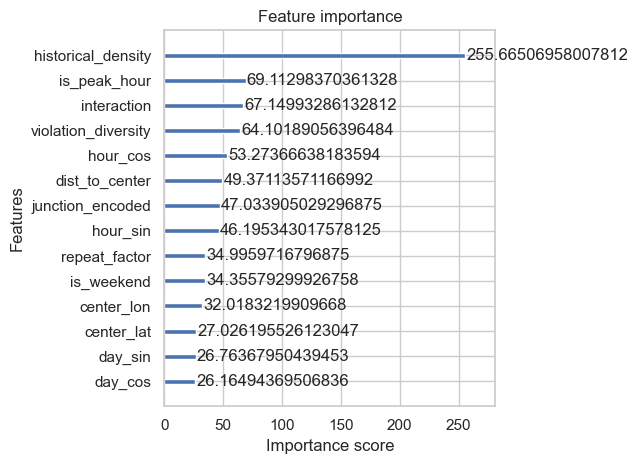

In [6]:
print("=" * 80)
print("PHASE 5 : SPATIO-TEMPORAL CONGESTION IMPACT MODEL")
print("=" * 80)

# ------------------------------------------------------------------
# STEP 1 : PREPARE TRAINING DATA
# ------------------------------------------------------------------

hourly_data = hotspot_records.groupby(
    ["hex_id", "day_of_week", "hour"]
).agg(
    violation_volume=("id", "count")
).reset_index()

hourly_data = hourly_data.merge(

    final_hotspots[
        [
            "hex_id",
            "center_lat",
            "center_lon",
            "primary_junction",
            "repeat_factor",
            "unique_violation_types",
            "total_volume"
        ]
    ],

    on="hex_id",
    how="left"

)

# ------------------------------------------------------------------
# STEP 2 : BASIC FEATURES
# ------------------------------------------------------------------

hourly_data["is_weekend"] = (
    hourly_data["day_of_week"]
    .isin(["Saturday", "Sunday"])
    .astype(int)
)

peak_hours = [8,9,10,11,17,18,19,20]

hourly_data["is_peak_hour"] = (
    hourly_data["hour"]
    .isin(peak_hours)
    .astype(int)
)

hourly_data["hour_sin"] = np.sin(
    2*np.pi*hourly_data.hour/24
)

hourly_data["hour_cos"] = np.cos(
    2*np.pi*hourly_data.hour/24
)

day_map = {
    "Monday":0,
    "Tuesday":1,
    "Wednesday":2,
    "Thursday":3,
    "Friday":4,
    "Saturday":5,
    "Sunday":6
}

hourly_data["day_idx"] = (
    hourly_data.day_of_week.map(day_map)
)

hourly_data["day_sin"] = np.sin(
    2*np.pi*hourly_data.day_idx/7
)

hourly_data["day_cos"] = np.cos(
    2*np.pi*hourly_data.day_idx/7
)

# ------------------------------------------------------------------
# STEP 3 : DISTANCE FEATURE
# ------------------------------------------------------------------

def haversine(lat1, lon1, lat2, lon2):

    lat1, lon1, lat2, lon2 = map(
        np.radians,
        [lat1, lon1, lat2, lon2]
    )

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = (
        np.sin(dlat/2)**2
        +
        np.cos(lat1)
        *
        np.cos(lat2)
        *
        np.sin(dlon/2)**2
    )

    c = 2*np.arcsin(np.sqrt(a))
    return 6371*c

hourly_data["dist_to_center"] = haversine(
    hourly_data.center_lat,
    hourly_data.center_lon,
    12.9716,
    77.5946
)

# ------------------------------------------------------------------
# STEP 4 : NEW CONTEXTUAL FEATURES
# ------------------------------------------------------------------

hourly_data["historical_density"] = np.log1p(
    hourly_data.total_volume
)

hourly_data["repeat_factor"] = (
    hourly_data.repeat_factor
)

hourly_data["violation_diversity"] = (
    hourly_data.unique_violation_types
)

hourly_data["interaction"] = (
    hourly_data.is_peak_hour
    *
    hourly_data.historical_density
)

# ------------------------------------------------------------------
# STEP 5 : JUNCTION ENCODING
# ------------------------------------------------------------------

hourly_data["primary_junction"] = (
    hourly_data["primary_junction"]
    .fillna("__UNKNOWN__")
    .astype(str)
)

known = list(
    hourly_data.primary_junction.unique()
)

if "__UNKNOWN__" not in known:
    known.append("__UNKNOWN__")

le_junc = LabelEncoder()
le_junc.fit(known)

hourly_data["junction_encoded"] = (
    le_junc.transform(
        hourly_data.primary_junction
    )
)

# ------------------------------------------------------------------
# STEP 6 : HYBRID CONGESTION IMPACT TARGET
# ------------------------------------------------------------------

# Peak hour multiplier

peak_hours = [8, 9, 10, 11, 17, 18, 19, 20]

hourly_data["time_multiplier"] = np.where(
    hourly_data["hour"].isin(peak_hours),
    1.2,
    1.0
)

# Junction multiplier

hourly_data["junction_multiplier"] = np.where(
    hourly_data["primary_junction"] == "No Junction",
    1.0,
    1.2
)

hourly_data["target_impact"] = (
    hourly_data["violation_volume"]
    *
    hourly_data["time_multiplier"]
    *
    hourly_data["junction_multiplier"]
)

# Normalize to 0-100

hourly_data["target_impact"] = (
    hourly_data["target_impact"]
    /
    hourly_data["target_impact"].max()
) * 100


# ------------------------------------------------------------------
# STEP 7 : FEATURES
# ------------------------------------------------------------------

features = [
    "center_lat",
    "center_lon",
    "is_weekend",
    "is_peak_hour",
    "hour_sin",
    "hour_cos",
    "day_sin",
    "day_cos",
    "dist_to_center",
    "junction_encoded",
    "historical_density",
    "repeat_factor",
    "violation_diversity",
    "interaction"
]

X = hourly_data[features]
y = hourly_data["target_impact"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

# ------------------------------------------------------------------
# STEP 8 : TRAIN MODEL just like Optuna said 
# ------------------------------------------------------------------

model = xgb.XGBRegressor(
    n_estimators=900,
    learning_rate=0.008293356933058608,
    max_depth=12,
    subsample=0.5694519618062028,
    colsample_bytree=0.7937399738922326,
    min_child_weight=4,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

pred = model.predict(X_test)

print()


r2   = r2_score(y_test, pred)
mae  = mean_absolute_error(y_test, pred)
mse  = mean_squared_error(y_test, pred)
rmse = np.sqrt(mse)
corr = np.corrcoef(
    y_test,
    pred
)[0,1]

print("="*30)
print(f"MAE                 : {mae:.4f}")
print(f"RMSE                : {rmse:.4f}")
print(f"MSE                 : {mse:.4f}")
print(f"R² Score            : {r2:.4f}")
print(f"Pearson Correlation : {corr:.4f}")
print("="*30)

importance = pd.DataFrame({
    "Feature": features,
    "Importance": model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

display(importance)

# ------------------------------------------------------------------
# STEP 9 : FEATURE IMPORTANCE
# ------------------------------------------------------------------

plt.figure(figsize=(10,6))

xgb.plot_importance(
    model,
    max_num_features=14,
    importance_type="gain"
)

plt.tight_layout()
plt.show()

# ⚡ Phase 6: Scaling Intelligence with GPU Optimization

To ensure our AI-driven intelligence is highly accurate and scalable for city-wide deployment, I utilize **Optuna** for Bayesian hyperparameter optimization. 

Recognizing the size of the dataset and the complexity of the trees required to understand urban traffic dynamics, I enable GPU-acceleration (`tree_method="hist"`, `device="cuda"`). I validate the model using strict 5-Fold Cross-Validation. This phase guarantees that the intelligence guiding our targeted enforcement is robust, mathematically sound, and capable of being rapidly retrained as new parking patterns emerge.

In [7]:
# ------------------------------------------------------------------
# GPU-ACCELERATED HYPERPARAMETER TUNING (RTX 4060) 
# ------------------------------------------------------------------
import optuna
import xgboost as xgb
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import KFold, train_test_split

print("Preparing data...")

# 1. Split the data to ensure X_train and y_train exist in memory 
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

# 2. Defining the Optuna objective function
def objective(trial):
    # Defining the search space
    param = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 1000, step=100),
        "learning_rate": trial.suggest_float("learning_rate", 1e-3, 0.1, log=True),
        "max_depth": trial.suggest_int("max_depth", 5, 15),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
        
        # --- CRITICAL GPU PARAMETERS FOR MY RTX 4060 ---
        "tree_method": "hist",
        "device": "cuda",
        "random_state": 42
    }

    # 5-Fold Cross-Validation setup
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    cv_rmse_scores = []

    for train_idx, val_idx in kf.split(X_train):
        # Use .iloc for safe pandas slicing
        X_tr, X_va = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_tr, y_va = y_train.iloc[train_idx], y_train.iloc[val_idx]

        # Initialize model with trial parameters
        model = xgb.XGBRegressor(**param)
        
        # Fit model
        model.fit(
            X_tr, y_tr,
            eval_set=[(X_va, y_va)],
            verbose=False
        )
        
        # Predict and calculate RMSE for this fold
        preds = model.predict(X_va)
        rmse = np.sqrt(mean_squared_error(y_va, preds))
        cv_rmse_scores.append(rmse)

    # Return average RMSE across all 5 folds
    return np.mean(cv_rmse_scores)

# 3. Create persistent SQLite study
# This saves locally to my laptop so I never lose progress
study_name = "xgb_congestion_local_gpu"
storage_name = f"sqlite:///{study_name}.db"

study = optuna.create_study(
    study_name=study_name,
    storage=storage_name,
    direction="minimize",
    load_if_exists=True
)

# 4. Run the optimization
# Set to 50 trials; my RTX 4060 should handle this very quickly
print("Starting GPU-accelerated hyperparameter search...")
study.optimize(objective, n_trials=50, show_progress_bar=True)

# 5. Extracting best parameters and train the FINAL model
print("\n" + "="*40)
print("Best Hyperparameters Found:")
for key, value in study.best_params.items():
    print(f"  {key}: {value}")
print("="*40)

# Apply best parameters and ensure GPU is used for the final training
best_params = study.best_params
best_params["tree_method"] = "hist"
best_params["device"] = "cuda"
best_params["random_state"] = 42

print("\nTraining final model with best parameters on full training set...")
final_model = xgb.XGBRegressor(**best_params)
final_model.fit(X_train, y_train)

# 6. Evaluate Final Model Performance
pred = final_model.predict(X_test)

r2   = r2_score(y_test, pred)
mae  = mean_absolute_error(y_test, pred)
mse  = mean_squared_error(y_test, pred)
rmse = np.sqrt(mse)
corr = np.corrcoef(y_test, pred)[0,1]

print("\n" + "="*40)
print("OPTIMIZED MODEL PERFORMANCE (TEST SET)")
print("="*40)
print(f"MAE                 : {mae:.4f}  (Baseline: 1.9058)")
print(f"RMSE                : {rmse:.4f}  (Baseline: 3.4082)")
print(f"MSE                 : {mse:.4f}  (Baseline: 11.2031)")
print(f"R² Score            : {r2:.4f}  (Baseline: 0.7044)")
print(f"Pearson Correlation : {corr:.4f}  (Baseline: 0.8403)")
print("="*40)

# 7. Display Feature Importances for the Optimized Model
features = X.columns.tolist() 
importance = pd.DataFrame({
    "Feature": features,
    "Importance": final_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

display(importance)

Preparing data...


[I 2026-06-22 01:04:37,196] A new study created in RDB with name: xgb_congestion_local_gpu


Starting GPU-accelerated hyperparameter search...


Best trial: 0. Best value: 2.44:   2%|▏         | 1/50 [00:09<08:09, 10.00s/it]

[I 2026-06-22 01:04:47,188] Trial 0 finished with value: 2.4400005465828363 and parameters: {'n_estimators': 700, 'learning_rate': 0.007165972030329973, 'max_depth': 7, 'subsample': 0.5980443857786863, 'colsample_bytree': 0.7326062447087295, 'min_child_weight': 3}. Best is trial 0 with value: 2.4400005465828363.


...

Best trial: 48. Best value: 2.36552:  98%|█████████▊| 49/50 [31:58<00:37, 37.01s/it]

[I 2026-06-22 01:36:35,907] Trial 48 finished with value: 2.3655168648830953 and parameters: {'n_estimators': 600, 'learning_rate': 0.012190437836652758, 'max_depth': 12, 'subsample': 0.5415585410965226, 'colsample_bytree': 0.978253544225822, 'min_child_weight': 3}. Best is trial 48 with value: 2.3655168648830953.


Best trial: 48. Best value: 2.36552: 100%|██████████| 50/50 [32:25<00:00, 38.91s/it]


[I 2026-06-22 01:37:02,614] Trial 49 finished with value: 2.367232098012905 and parameters: {'n_estimators': 600, 'learning_rate': 0.01181894576067456, 'max_depth': 12, 'subsample': 0.5467992336998817, 'colsample_bytree': 0.9828498426113697, 'min_child_weight': 3}. Best is trial 48 with value: 2.3655168648830953.

Best Hyperparameters Found:
  n_estimators: 600
  learning_rate: 0.012190437836652758
  max_depth: 12
  subsample: 0.5415585410965226
  colsample_bytree: 0.978253544225822
  min_child_weight: 3

Training final model with best parameters on full training set...

OPTIMIZED MODEL PERFORMANCE (TEST SET)
MAE                 : 1.0855  (Baseline: 1.9058)
RMSE                : 2.3281  (Baseline: 3.4082)
MSE                 : 5.4201  (Baseline: 11.2031)
R² Score            : 0.7099  (Baseline: 0.7044)
Pearson Correlation : 0.8426  (Baseline: 0.8403)


,Feature,Importance
10,historical_density,0.392374
13,interaction,0.086907
5,hour_cos,0.064600
4,hour_sin,0.058846
12,violation_diversity,0.053619
8,dist_to_center,0.051956
3,is_peak_hour,0.048345
2,is_weekend,0.043761
9,junction_encoded,0.037927
1,center_lon,0.035761


# 🚀 Phase 7: Operationalizing Targeted Enforcement (MLOps)

**The Goal:** Fulfilling the hackathon mandate to "enable targeted enforcement."

A model sitting in a Jupyter Notebook cannot redirect traffic police. To solve the operational challenge, we must make our intelligence deployable. In this final phase, I serialize my XGBoost model, Encoders, Metadata, and the final Hotspot JSON payloads. 

By saving these artifacts, I provide a complete, production-ready backend. These outputs can immediately be plugged into a live API, feeding direct routing intelligence to patrol officers' mobile devices, effectively ending the era of blind, reactive enforcement.

In [10]:
import os
import json
import joblib

ARTIFACT_DIR = "artifacts"
os.makedirs(ARTIFACT_DIR, exist_ok=True)

# Save trained XGBoost model
joblib.dump(
    model,
    os.path.join(ARTIFACT_DIR, "xgb_master.pkl")
)

# Save junction label encoder
joblib.dump(
    le_junc,
    os.path.join(ARTIFACT_DIR, "junction_encoder.pkl")
)

# Save metadata
meta = {
    "feature_order": features,
    "city_center": {
        "lat": 12.9716,
        "lon": 77.5946
    },
    "hex_resolution": 9,
    "peak_hours": [8, 9, 10, 11, 17, 18, 19, 20],
    "unknown_junction_label": "__UNKNOWN__"
}

joblib.dump(
    meta,
    os.path.join(ARTIFACT_DIR, "meta.pkl")
)

# Save hotspot information for inference
final_hotspots.to_json(
    os.path.join(ARTIFACT_DIR, "final_hotspots.json"),
    orient="records",
    indent=4
)

print("=" * 30)
print("Artifacts saved successfully!")
print(f"Location: {ARTIFACT_DIR}")
print("=" * 30)

Artifacts saved successfully!
Location: artifacts
